In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import genpareto

In [82]:
MU_PRIME = 1e-3 # Deaths / thousand / year units
SMU_THRESH = MU_PRIME * 10

In [83]:
marani_raw = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
marani_raw['intensity'] = marani_raw['severity_perthousand'] / marani_raw['duration']

In [84]:
marani_classic_ds = marani_raw[marani_raw['year_end'].between(1600, 1945)]
marani_classic_ds['intensity'] = marani_classic_ds['severity_perthousand'] / marani_classic_ds['duration']
marani_classic_ds = marani_classic_ds[marani_classic_ds['intensity'] > MU_PRIME]

C:\Users\squaade\AppData\Local\Temp\ipykernel_63212\12892478.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marani_classic_ds['intensity'] = marani_classic_ds['severity_perthousand'] / marani_classic_ds['duration']


(398, 16)

In [85]:
marani_classic_sev_params = genpareto.fit(marani_classic_ds['severity_smu'], floc=SMU_THRESH)
marani_classic_int_params = genpareto.fit(marani_classic_ds['intensity'], floc=MU_PRIME)
marani_classic_sev_params, marani_classic_int_params

((np.float64(1.891663388514921), 0.01, np.float64(0.2608645673124628)),
 (np.float64(1.430665706247872), 0.001, np.float64(0.01163664964569524)))

### Now try fitting these distributions just with your data.

In [94]:
our_df = marani_raw[marani_raw['year_start'] >= 1900]
our_df = our_df[our_df['severity_smu'] >= SMU_THRESH]
our_df = our_df[our_df['disease'].isin(['influenza', 'covid-19', 'ebola', 'hiv/aids'])].reset_index(drop=True)

In [95]:
our_df_no_new = our_df[~our_df['disease'].isin(['covid-19', 'hiv/aids'])]

In [99]:
## Get original COVID-19 severity and replace with ex ante estimate
original_covid_severity = our_df.loc[our_df['disease'] == 'covid-19', 'severity_smu'].values[0]

with open("../../data/clean/inverted_covid_severity.yaml") as f:
		estimated_covid_severity = yaml.safe_load(f)

ex_ante_covid_severity = estimated_covid_severity['ex_ante_severity']

our_df_natural_covid = our_df.copy()
our_df_natural_covid.loc[our_df_natural_covid['disease'] == 'covid-19', 'severity_smu'] = ex_ante_covid_severity
our_df_natural_covid['intensity'] = (our_df_natural_covid['severity_smu'] / 10) / our_df_natural_covid['duration'] # Recalculate intensity

In [100]:
# Fit distributions for our different datasets
our_df_sev_params = genpareto.fit(our_df['severity_smu'], floc=SMU_THRESH)
our_df_int_params = genpareto.fit(our_df['intensity'], floc=MU_PRIME)

our_df_no_new_sev_params = genpareto.fit(our_df_no_new['severity_smu'], floc=SMU_THRESH)
our_df_no_new_int_params = genpareto.fit(our_df_no_new['intensity'], floc=MU_PRIME)

our_df_natural_covid_sev_params = genpareto.fit(our_df_natural_covid['severity_smu'], floc=SMU_THRESH)
our_df_natural_covid_int_params = genpareto.fit(our_df_natural_covid['intensity'], floc=MU_PRIME)

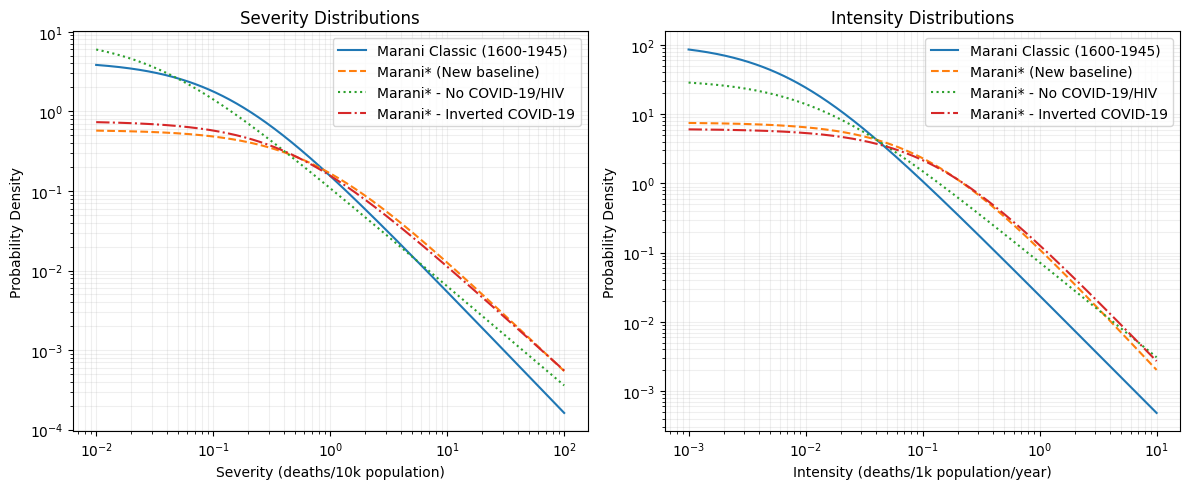


Severity Parameters (shape, loc, scale):
Marani Classic: (np.float64(1.891663388514921), 0.01, np.float64(0.2608645673124628))
Full Modern: (np.float64(2.504882508798669), 0.01, np.float64(1.7457313371472198))
No New Diseases: (np.float64(4.039074872739469), 0.01, np.float64(0.16698849172658556))
Natural COVID: (np.float64(3.048483854136432), 0.01, np.float64(1.3661770016653416))

Intensity Parameters (shape, loc, scale):
Marani Classic: (np.float64(1.430665706247872), 0.001, np.float64(0.01163664964569524))
Full Modern: (np.float64(1.230404957130518), 0.001, np.float64(0.13388942029227785))
No New Diseases: (np.float64(2.64388507927724), 0.001, np.float64(0.03497202076582817))
Natural COVID: (np.float64(1.3264904829263635), 0.001, np.float64(0.1657173116565877))


In [132]:

# Create plots comparing distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot severity distributions
x_sev = np.logspace(np.log10(SMU_THRESH), 2, 1000)
ax1.plot(x_sev, genpareto.pdf(x_sev, *marani_classic_sev_params), 
         label='Marani Classic (1600-1945)', linestyle='-')
ax1.plot(x_sev, genpareto.pdf(x_sev, *our_df_sev_params),
         label='Marani* (New baseline)', linestyle='--')
ax1.plot(x_sev, genpareto.pdf(x_sev, *our_df_no_new_sev_params),
         label='Marani* - No COVID-19/HIV', linestyle=':')
ax1.plot(x_sev, genpareto.pdf(x_sev, *our_df_natural_covid_sev_params),
         label='Marani* - Inverted COVID-19', linestyle='-.')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Severity (deaths/10k population)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Severity Distributions')
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Plot intensity distributions
orig_marani_classic_int_params = (1.41, 1e-3, 0.0113)
x_int = np.logspace(np.log10(MU_PRIME), 1, 1000)
ax2.plot(x_int, genpareto.pdf(x_int, *marani_classic_int_params),
         label='Marani Classic (1600-1945)')
ax2.plot(x_int, genpareto.pdf(x_int, *our_df_int_params),
         label='Marani* (New baseline)', linestyle='--')
ax2.plot(x_int, genpareto.pdf(x_int, *our_df_no_new_int_params),
         label='Marani* - No COVID-19/HIV', linestyle=':')
ax2.plot(x_int, genpareto.pdf(x_int, *our_df_natural_covid_int_params),
         label='Marani* - Inverted COVID-19', linestyle='-.')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Intensity (deaths/1k population/year)')
ax2.set_ylabel('Probability Density')
ax2.set_title('Intensity Distributions')
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

# Print the parameters for reference
print("\nSeverity Parameters (shape, loc, scale):")
print(f"Marani Classic: {marani_classic_sev_params}")
print(f"Full Modern: {our_df_sev_params}")
print(f"No New Diseases: {our_df_no_new_sev_params}")
print(f"Natural COVID: {our_df_natural_covid_sev_params}")

print("\nIntensity Parameters (shape, loc, scale):")
print(f"Marani Classic: {marani_classic_int_params}")
print(f"Full Modern: {our_df_int_params}")
print(f"No New Diseases: {our_df_no_new_int_params}")
print(f"Natural COVID: {our_df_natural_covid_int_params}")


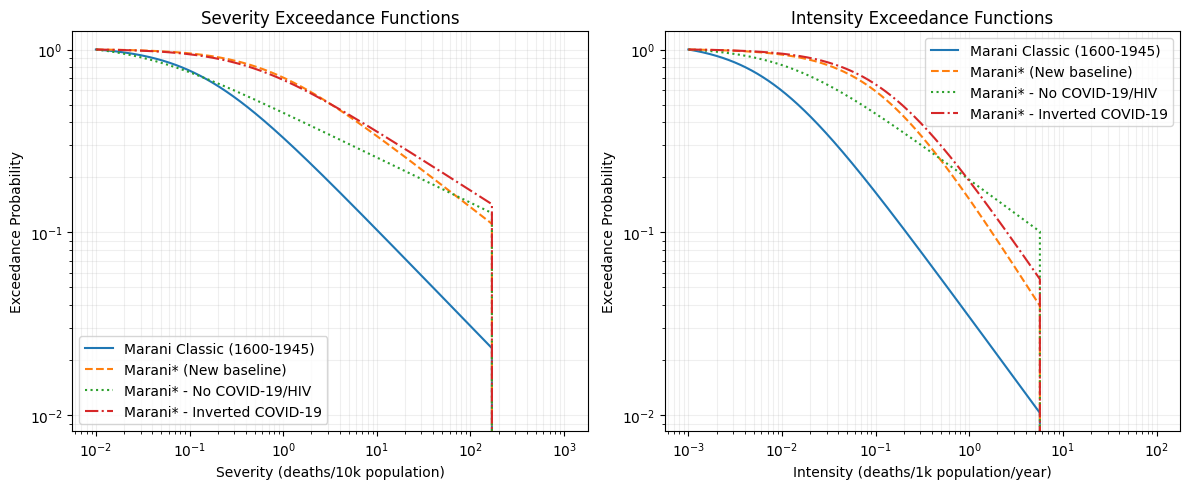

In [133]:
# Create figure for truncated exceedance functions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Set up x values for severity and intensity
x_sev = np.logspace(np.log10(SMU_THRESH), 3, 1000)
x_int = np.logspace(np.log10(MU_PRIME), 2, 1000)

# Calculate and plot exceedance probabilities for severity
def calc_exceedance(x, params):
    """
    Calculate exceedance probability for generalized Pareto distribution
    with upper truncation
    """
    shape, loc, scale = params
    exceed_prob = 1 - genpareto.cdf(x, shape, loc, scale)
    # Set to 0 for values above truncation point
    exceed_prob = np.where(x > 171, 0, exceed_prob)
    return exceed_prob

# Plot severity exceedance functions
ax1.plot(x_sev, calc_exceedance(x_sev, marani_classic_sev_params),
         label='Marani Classic (1600-1945)')
ax1.plot(x_sev, calc_exceedance(x_sev, our_df_sev_params),
         label='Marani* (New baseline)', linestyle='--')
ax1.plot(x_sev, calc_exceedance(x_sev, our_df_no_new_sev_params),
         label='Marani* - No COVID-19/HIV', linestyle=':')
ax1.plot(x_sev, calc_exceedance(x_sev, our_df_natural_covid_sev_params),
         label='Marani* - Inverted COVID-19', linestyle='-.')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Severity (deaths/10k population)')
ax1.set_ylabel('Exceedance Probability')
ax1.set_title('Severity Exceedance Functions')
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Plot intensity exceedance functions
def calc_exceedance_int(x, params):
    """
    Calculate exceedance probability for intensity distribution
    with upper truncation at 5.7
    """
    shape, loc, scale = params
    exceed_prob = 1 - genpareto.cdf(x, shape, loc, scale)
    # Set to 0 for values above truncation point
    exceed_prob = np.where(x > 5.7, 0, exceed_prob)
    return exceed_prob

ax2.plot(x_int, calc_exceedance_int(x_int, marani_classic_int_params),
         label='Marani Classic (1600-1945)')
ax2.plot(x_int, calc_exceedance_int(x_int, our_df_int_params),
         label='Marani* (New baseline)', linestyle='--')
ax2.plot(x_int, calc_exceedance_int(x_int, our_df_no_new_int_params),
         label='Marani* - No COVID-19/HIV', linestyle=':')
ax2.plot(x_int, calc_exceedance_int(x_int, our_df_natural_covid_int_params),
         label='Marani* - Inverted COVID-19', linestyle='-.')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Intensity (deaths/1k population/year)')
ax2.set_ylabel('Exceedance Probability')
ax2.set_title('Intensity Exceedance Functions')
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

# Set same y-axis limits for both plots
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


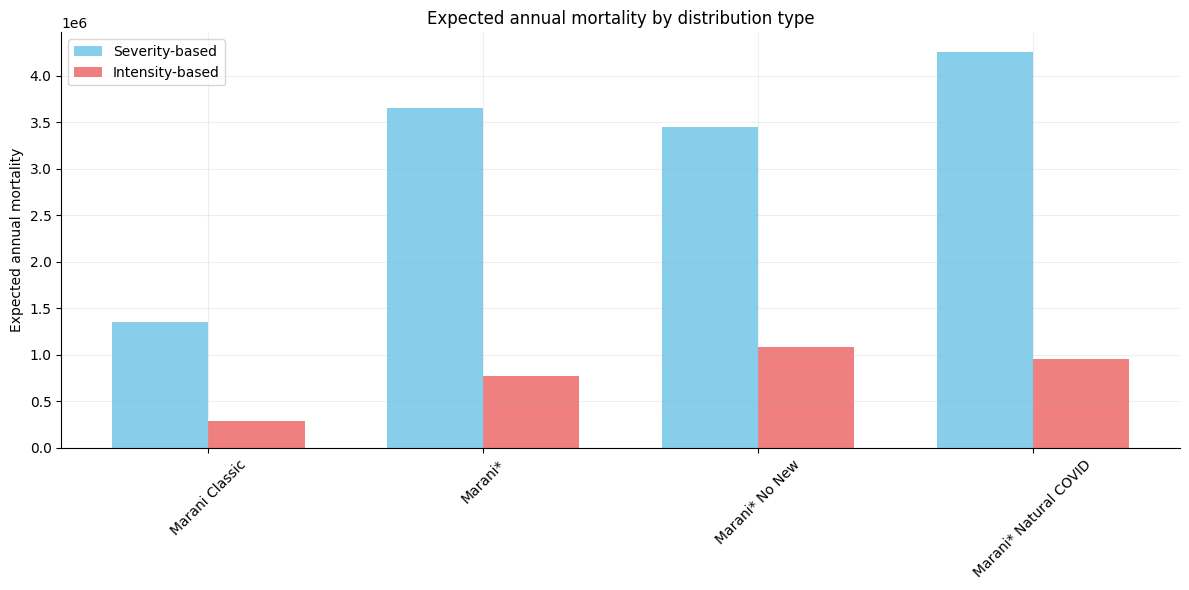


Expected annual mortality:
Marani Classic (Severity): 1355305.7533
Marani Classic (Intensity): 280898.3146
Marani* (Severity): 3648715.6270
Marani* (Intensity): 767117.7131
Marani* No New (Severity): 3446457.3427
Marani* No New (Intensity): 1080088.3523
Marani* Natural COVID (Severity): 4253319.4564
Marani* Natural COVID (Intensity): 953281.1687


In [134]:
# Set random seed for reproducibility
np.random.seed(42)
n_sims = 1000000
uniform_draws = np.random.random(n_sims)

def simulate_annual_mortality(dist_params, arrival_prob, uniform_draws, is_intensity=False):
    """
    Simulate annual mortality using either severity or intensity distribution parameters
    
    Args:
        dist_params: Tuple of (shape, loc, scale) for generalized Pareto distribution
        arrival_prob: Annual probability of event occurrence
        uniform_draws: Uniform random numbers for quantile transformation
        is_intensity: Boolean indicating if distribution is for intensity (True) or severity (False)
    
    Returns:
        Array of simulated annual mortalities
    """
    # Adjust uniform draws based on arrival probability
    # Values below (1-arrival_prob) become 0, others are rescaled to [0,1]
    adjusted_draws = np.where(
        uniform_draws >= (1 - arrival_prob),
        (uniform_draws - (1 - arrival_prob)) / arrival_prob,
        0
    )
    
    # Generate mortalities (0 where adjusted_draws is 0)
    mortalities = np.zeros(n_sims)
    event_mask = adjusted_draws > 0
    mortalities[event_mask] = genpareto.ppf(adjusted_draws[event_mask], *dist_params)
    
    # Apply appropriate truncation threshold
    truncation = 5.7 if is_intensity else 171
    mortalities = np.where(
        mortalities > truncation,
        truncation,
        mortalities
    )
    
    return mortalities

# Annual arrival probabilities
p_classic = 0.21
p_modern = 0.15
N0 = 7.91e9

# Simulate annual mortalities for each distribution
results = {
    'Marani Classic (Severity)': simulate_annual_mortality(marani_classic_sev_params, p_classic, uniform_draws, False),
    'Marani Classic (Intensity)': simulate_annual_mortality(marani_classic_int_params, p_classic, uniform_draws, True),
    'Marani* (Severity)': simulate_annual_mortality(our_df_sev_params, p_modern, uniform_draws, False),
    'Marani* (Intensity)': simulate_annual_mortality(our_df_int_params, p_modern, uniform_draws, True),
    'Marani* No New (Severity)': simulate_annual_mortality(our_df_no_new_sev_params, p_modern, uniform_draws, False),
    'Marani* No New (Intensity)': simulate_annual_mortality(our_df_no_new_int_params, p_modern, uniform_draws, True),
    'Marani* Natural COVID (Severity)': simulate_annual_mortality(our_df_natural_covid_sev_params, p_modern, uniform_draws, False),
    'Marani* Natural COVID (Intensity)': simulate_annual_mortality(our_df_natural_covid_int_params, p_modern, uniform_draws, True)
}

# Calculate means
means = {k: (v.mean() * 10 if 'Intensity' in k else v.mean()) for k, v in results.items()}
means = {k: v * N0 / 1e4 for k, v in means.items()}

# Create grouped bar plot
plt.figure(figsize=(12, 6))

# Set positions for bars
x = np.arange(4)
width = 0.35

# Plot bars
plt.bar(x - width/2, 
        [means['Marani Classic (Severity)'], means['Marani* (Severity)'],
         means['Marani* No New (Severity)'], means['Marani* Natural COVID (Severity)']],
        width, label='Severity-based', color='skyblue')
plt.bar(x + width/2, 
        [means['Marani Classic (Intensity)'], means['Marani* (Intensity)'],
         means['Marani* No New (Intensity)'], means['Marani* Natural COVID (Intensity)']],
        width, label='Intensity-based', color='lightcoral')

# Customize plot
plt.ylabel('Expected annual mortality')
plt.title('Expected annual mortality by distribution type')
plt.xticks(x, ['Marani Classic', 'Marani*', 'Marani* No New', 'Marani* Natural COVID'], 
           rotation=45)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

# Print numerical results
print("\nExpected annual mortality:")
for k, v in means.items():
    print(f"{k}: {v:.4f}")


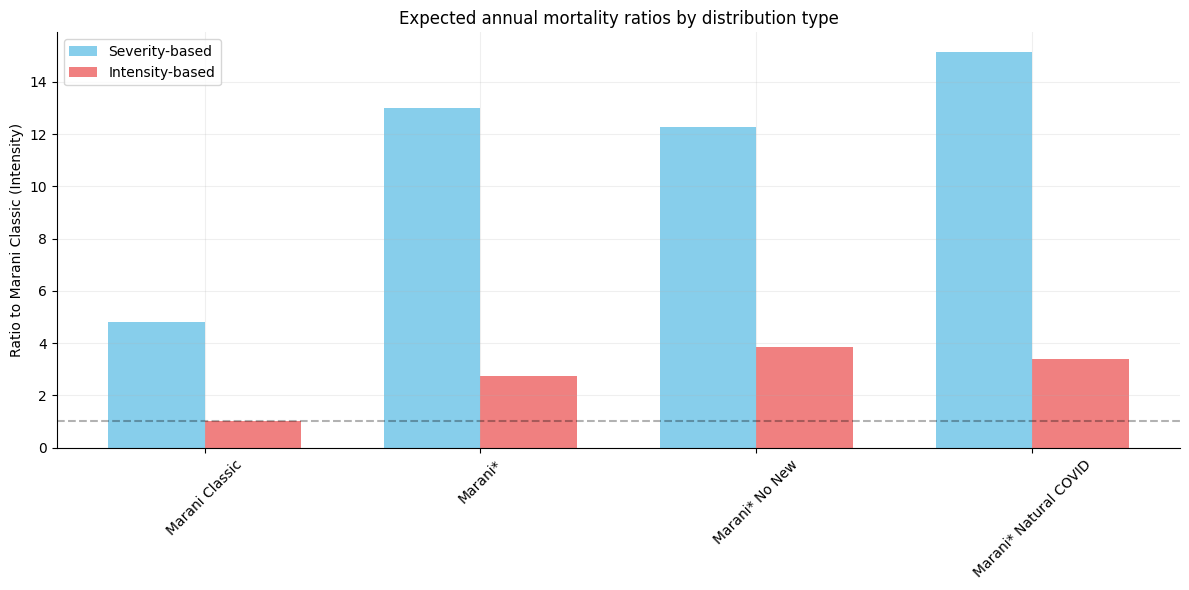


Mortality ratios relative to Marani Classic (Intensity):
Marani Classic (Severity): 4.8249
Marani Classic (Intensity): 1.0000
Marani* (Severity): 12.9895
Marani* (Intensity): 2.7309
Marani* No New (Severity): 12.2694
Marani* No New (Intensity): 3.8451
Marani* Natural COVID (Severity): 15.1418
Marani* Natural COVID (Intensity): 3.3937


In [135]:
# Calculate ratios relative to Marani Classic (Intensity)
baseline = means['Marani Classic (Intensity)']
ratios = {k: v/baseline for k, v in means.items()}

# Create grouped bar plot
plt.figure(figsize=(12, 6))

# Set positions for bars
x = np.arange(4)
width = 0.35

# Plot bars
plt.bar(x - width/2, 
        [ratios['Marani Classic (Severity)'], ratios['Marani* (Severity)'],
         ratios['Marani* No New (Severity)'], ratios['Marani* Natural COVID (Severity)']],
        width, label='Severity-based', color='skyblue')
plt.bar(x + width/2, 
        [ratios['Marani Classic (Intensity)'], ratios['Marani* (Intensity)'],
         ratios['Marani* No New (Intensity)'], ratios['Marani* Natural COVID (Intensity)']],
        width, label='Intensity-based', color='lightcoral')

# Add horizontal line at y=1
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)

# Customize plot
plt.ylabel('Ratio to Marani Classic (Intensity)')
plt.title('Expected annual mortality ratios by distribution type')
plt.xticks(x, ['Marani Classic', 'Marani*', 'Marani* No New', 'Marani* Natural COVID'], 
           rotation=45)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

# Print numerical ratios
print("\nMortality ratios relative to Marani Classic (Intensity):")
for k, v in ratios.items():
    print(f"{k}: {v:.4f}")
